In [ ]:
# 09 — Robustness Checks

Two questions about whether the earlier results can be trusted:

1. Is the macro F1 of 0.338 stable, or an accident of one train/test split?
   Answered with GroupKFold cross-validation, grouped by match.
2. How precise is the counterfactual estimate? Answered with a cluster
   bootstrap over matches.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
import pickle
from pathlib import Path

from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import f1_score, accuracy_score
from xgboost import XGBClassifier

sns.set_style("whitegrid")

CWD = Path.cwd()
PROJECT_ROOT = CWD if (CWD / "data").exists() else CWD.parent
PROCESSED = PROJECT_ROOT / "data" / "processed"
FIGURES = PROJECT_ROOT / "figures"

data = pd.read_parquet(PROCESSED / "model_data.parquet")

CATEGORICAL = ["shot_type", "direction", "direction_pattern", "to_opponent_wing",
               "prev_shot_type", "prev_direction", "prev_depth",
               "serve_direction", "pressure_context", "Surface", "gender"]
NUMERIC = ["shot_number", "is_approach", "prev_approach",
           "is_serving", "is_second_serve"]

for col in CATEGORICAL:
    data[col] = data[col].fillna("none").astype(str)
for col in NUMERIC:
    data[col] = data[col].fillna(0).astype(float)

CLASSES = ["in_play", "unforced_error", "forced_error", "winner"]
label_to_int = {name: i for i, name in enumerate(CLASSES)}

print("Data:", data.shape)

Data: (5207197, 21)


In [2]:
# GroupKFold keeps all shots from one match inside a single fold. Without
# this, shots from the same match would appear in both training and
# validation, and the scores would be too optimistic.
FOLDS = 5
SAMPLE_PER_FOLD = 300_000

splitter = GroupKFold(n_splits=FOLDS)
fold_results = []

for fold, (train_idx, valid_idx) in enumerate(
        splitter.split(data, groups=data["match_id"]), start=1):

    train = data.iloc[train_idx].sample(
        min(SAMPLE_PER_FOLD, len(train_idx)), random_state=fold)
    valid = data.iloc[valid_idx]

    encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
    encoder.fit(train[CATEGORICAL])

    def build(df):
        return sp.hstack([encoder.transform(df[CATEGORICAL]),
                          sp.csr_matrix(df[NUMERIC].values)]).tocsr()

    y_train = train["target_outcome"].map(label_to_int).values
    y_valid = valid["target_outcome"].map(label_to_int).values

    counts = pd.Series(y_train).value_counts()
    weights = pd.Series(y_train).map(
        len(y_train) / (len(CLASSES) * counts)).values

    model = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
                          tree_method="hist", n_jobs=-1, random_state=42)
    model.fit(build(train), y_train, sample_weight=weights)

    predicted = model.predict(build(valid))
    fold_results.append({
        "fold": fold,
        "matches": valid["match_id"].nunique(),
        "shots": len(valid),
        "accuracy": accuracy_score(y_valid, predicted),
        "macro_f1": f1_score(y_valid, predicted, average="macro"),
    })
    print(f"Fold {fold}: macro F1 = {fold_results[-1]['macro_f1']:.4f}")

cv = pd.DataFrame(fold_results)
print(f"\nMean macro F1: {cv['macro_f1'].mean():.4f} "
      f"(sd {cv['macro_f1'].std():.4f})")

Fold 1: macro F1 = 0.3345
Fold 2: macro F1 = 0.3346
Fold 3: macro F1 = 0.3404
Fold 4: macro F1 = 0.3372
Fold 5: macro F1 = 0.3367

Mean macro F1: 0.3367 (sd 0.0024)


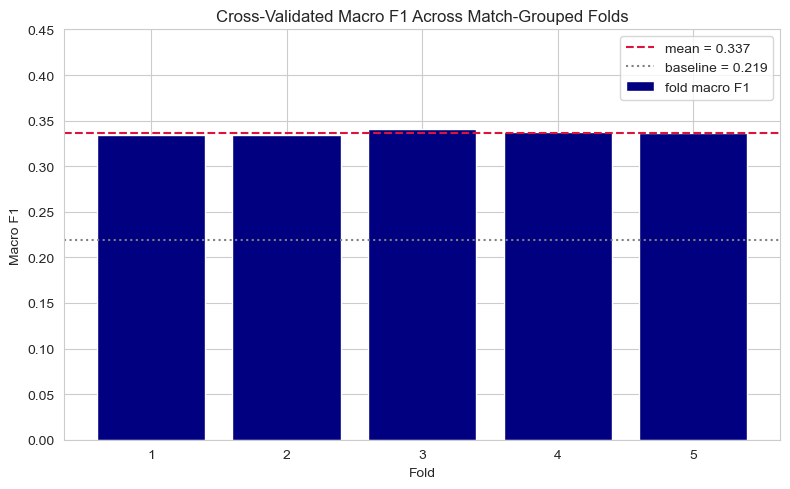

 fold  matches   shots  accuracy  macro_f1
    1     1833 1041440    0.3973    0.3345
    2     1834 1041437    0.3902    0.3346
    3     1835 1041441    0.4010    0.3404
    4     1834 1041441    0.3954    0.3372
    5     1838 1041438    0.3950    0.3367


In [3]:
# A small spread across folds means the single-split result was not luck.
plt.figure(figsize=(8, 5))
plt.bar(cv["fold"], cv["macro_f1"], color="navy", label="fold macro F1")
plt.axhline(cv["macro_f1"].mean(), color="crimson", linestyle="--",
            label=f"mean = {cv['macro_f1'].mean():.3f}")
plt.axhline(0.2188, color="grey", linestyle=":", label="baseline = 0.219")
plt.title("Cross-Validated Macro F1 Across Match-Grouped Folds")
plt.xlabel("Fold")
plt.ylabel("Macro F1")
plt.ylim(0, 0.45)
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES / "cv_stability.png", dpi=150)
plt.show()

cv.to_csv(FIGURES / "cross_validation_results.csv", index=False)
print(cv.round(4).to_string(index=False))

In [4]:
# Reload the unweighted probability model used for counterfactuals.
with open(PROCESSED / "model_artifacts.pkl", "rb") as f:
    artifacts = pickle.load(f)

cf_encoder = artifacts["encoder"]
cf_model = artifacts["xgb"]

PATTERNS = ["cross_court", "down_the_line", "middle"]


def counterfactual_net_value(subset):
    """
    Re-score the same shots under each direction, changing nothing else.
    Returns the net value (winner + forced error - unforced error) per pattern.
    """
    results = {}
    for pattern in PATTERNS:
        scenario = subset.copy()
        scenario["direction_pattern"] = pattern

        matrix = sp.hstack([cf_encoder.transform(scenario[CATEGORICAL]),
                            sp.csr_matrix(scenario[NUMERIC].values)]).tocsr()
        probabilities = cf_model.predict_proba(matrix).mean(axis=0)

        results[pattern] = (probabilities[CLASSES.index("winner")]
                            + probabilities[CLASSES.index("forced_error")]
                            - probabilities[CLASSES.index("unforced_error")])
    return results


# Only rally shots can have a direction pattern.
rally_shots = data[data["direction_pattern"] != "none"]
print("Rally shots available:", len(rally_shots))

Rally shots available: 4012042


In [5]:
# Resampling is done over MATCHES, not over individual shots. Shots within a
# match are correlated, so resampling shots would understate the uncertainty.
# This is a cluster bootstrap.
BOOTSTRAP_ROUNDS = 200
SHOTS_PER_ROUND = 20_000

match_ids = rally_shots["match_id"].unique()
rng = np.random.default_rng(42)

by_match = {m: g for m, g in rally_shots.groupby("match_id", observed=True)}

bootstrap_rows = []
for round_number in range(BOOTSTRAP_ROUNDS):
    sampled_matches = rng.choice(match_ids, size=400, replace=True)
    sample = pd.concat([by_match[m] for m in sampled_matches])
    if len(sample) > SHOTS_PER_ROUND:
        sample = sample.sample(SHOTS_PER_ROUND, random_state=round_number)

    values = counterfactual_net_value(sample)
    values["round"] = round_number
    bootstrap_rows.append(values)

    if (round_number + 1) % 50 == 0:
        print(f"{round_number + 1} / {BOOTSTRAP_ROUNDS} rounds done")

bootstrap = pd.DataFrame(bootstrap_rows)
bootstrap["dtl_minus_cc"] = (bootstrap["down_the_line"]
                            - bootstrap["cross_court"])
print("\nDone.")

50 / 200 rounds done
100 / 200 rounds done
150 / 200 rounds done
200 / 200 rounds done

Done.


In [6]:
# Percentile intervals: the middle 95% of the bootstrap distribution.
summary = []
for column in PATTERNS + ["dtl_minus_cc"]:
    values = bootstrap[column]
    summary.append({
        "quantity": column,
        "estimate": values.mean(),
        "ci_low": values.quantile(0.025),
        "ci_high": values.quantile(0.975),
    })

ci = pd.DataFrame(summary)
print(ci.round(4).to_string(index=False))

difference = bootstrap["dtl_minus_cc"]
print(f"\nShare of bootstrap rounds where down-the-line beats cross-court: "
      f"{(difference > 0).mean():.1%}")

     quantity  estimate  ci_low  ci_high
  cross_court    0.0216  0.0187   0.0246
down_the_line    0.0282  0.0246   0.0318
       middle    0.0293  0.0263   0.0324
 dtl_minus_cc    0.0066  0.0054   0.0076

Share of bootstrap rounds where down-the-line beats cross-court: 100.0%


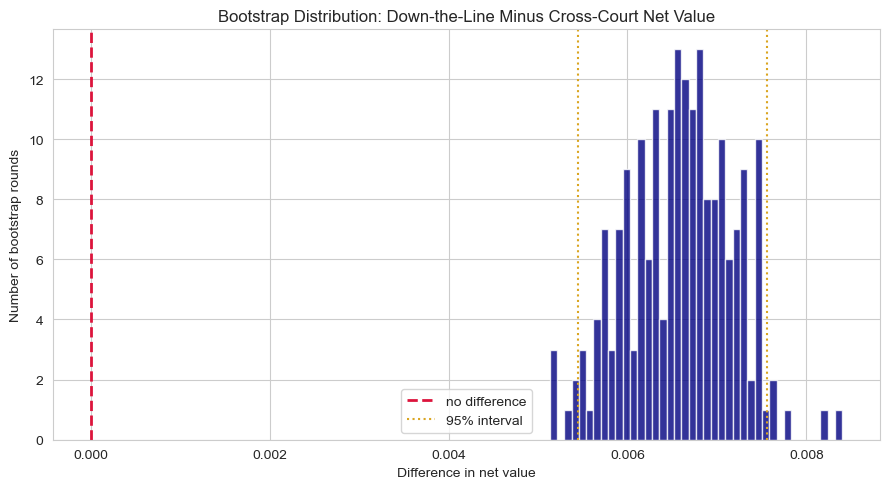

In [7]:
plt.figure(figsize=(9, 5))
plt.hist(bootstrap["dtl_minus_cc"], bins=40, color="navy", alpha=0.8)
plt.axvline(0, color="crimson", linestyle="--", linewidth=2,
            label="no difference")
plt.axvline(difference.quantile(0.025), color="goldenrod", linestyle=":",
            label="95% interval")
plt.axvline(difference.quantile(0.975), color="goldenrod", linestyle=":")
plt.title("Bootstrap Distribution: Down-the-Line Minus Cross-Court Net Value")
plt.xlabel("Difference in net value")
plt.ylabel("Number of bootstrap rounds")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES / "bootstrap_direction_difference.png", dpi=150)
plt.show()

ci.to_csv(FIGURES / "bootstrap_intervals.csv", index=False)